# Galaxy–CMB Lensing Cross-Correlation Pipeline for Cosmological Parameter Inference using PoCoMC and CosmoPower

*Estimate ΛCDM cosmological parameters from simulated observational spectra using Bayesian inference and neural-network emulated power spectra.*



| **Component**                | **Description**                                                                 |
|-----------------------------|---------------------------------------------------------------------------------|
| **Purpose**                 | Estimate cosmological parameters via galaxy–CMB lensing cross-correlation.     |
| **Core Model**              | Implements ΛCDM cosmology: Hubble function, growth factors, lensing kernels.   |
| **Power Spectrum**          | Uses CosmoPower (neural net emulator) to compute P(k, z).                      |
| **Angular Projection**      | Applies Limber approximation to project 3D spectra into 2D angular space.      |
| **Inference Method**        | Uses PoCoMC MCMC sampling with physical priors on key parameters.              |
| **Uncertainty Estimation**  | Constructs covariance matrices and log-likelihood function for robustness.     |
| **Result Visualization**    | Generates trace plots, histograms, and corner plots for posteriors.            |
| **Key Parameters Estimated**|  H₀, Ω_b h², Ω_c h², nₛ, Aₛ from fiducial/simulated observational spectra.      |

**Author**: Adrita Khan  
**Date**: 05.08.2025


- **Installing/Upgrading Required Packages**

In [1]:
!pip install -q --upgrade pip
!pip install -q --upgrade pocomc cosmopower astropy getdist corner gdown # Install or upgrade all required packages

- **Check Installed Package Versions**

In [2]:
# Check and print the version of required packages, or indicate if they are not installed

import pkg_resources

packages = ['pocomc', 'cosmopower', 'astropy', 'getdist', 'gdown', 'corner']

for package in packages:
    try:
        version = pkg_resources.get_distribution(package).version
        print(f"{package} version: {version}")
    except pkg_resources.DistributionNotFound:
        print(f"{package} is not installed.")

pocomc version: 1.2.6
cosmopower version: 0.2.0
astropy version: 6.1.7
getdist version: 1.7.1
gdown version: 5.2.0
corner version: 2.2.3


/tmp/ipykernel_7443/1600845929.py:3: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  import pkg_resources


- **Import Essential Libraries**

In [3]:
# Essential libraries for cosmology, sampling, and plotting

import os                     # OS operations
import gdown                  # Google Drive downloads
import numpy as np            # Numerical operations
import matplotlib.pyplot as plt  # Plotting
from scipy.stats import uniform, norm  # Distributions
import pocomc as pc           # PoCoMC sampler
import cosmopower as cp       # Power spectrum emulator
from astropy.cosmology import FlatLambdaCDM, Planck18  # Cosmology models
from scipy.integrate import quad  # Integration
import getdist                # MCMC analysis
from getdist import MCSamples, plots  # MCMC plotting
import corner                 # Posterior visualization
import warnings
warnings.filterwarnings('ignore') # Suppress warnings

2025-08-05 16:39:34.230484: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-08-05 16:39:34.270900: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-08-05 16:39:35.178460: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


- **Define Fiducial Parameters and Constants**

In [4]:
# Fiducial cosmological parameters
params = {
    'omega_b': [0.0225],        # Baryon density
    'omega_cdm': [0.113],       # Cold dark matter density
    'h': [0.7],                 # Hubble parameter
    'tau_reio': [0.055],        # Optical depth
    'n_s': [0.96],              # Spectral index
    'ln10^{10}A_s': [3.07],     # Scalar amplitude
}

# Constants
c = 299792.458  # Speed of light (km/s)
alpha = 2.225   # Magnification bias

- **Load CosmoPower Emulator**

In [5]:
# CosmoPower Model Setup

# --- Step 1: Set Up CosmoPower Emulator ---
# Download pre-trained model

os.makedirs("home", exist_ok=True)  # Create dir
os.makedirs("plots", exist_ok=True)

gdown.download('https://drive.google.com/uc?id=1h-IxTLoyTE6L3_uE9omjDNC-8X_uVAie', 'home/PKLIN_NN.pkl', quiet=False)  # Download model

cp_nn = cp.cosmopower_NN(restore=True, restore_filename='home/PKLIN_NN')  # Load model

Downloading...
From: https://drive.google.com/uc?id=1h-IxTLoyTE6L3_uE9omjDNC-8X_uVAie
To: /teamspace/studios/this_studio/home/PKLIN_NN.pkl
100%|██████████| 3.00M/3.00M [00:00<00:00, 140MB/s]

In [6]:
print('emulator parameters: ', cp_nn.parameters)

emulator parameters:  ListWrapper(['omega_b', 'omega_cdm', 'h', 'n_s', 'ln10^{10}A_s', 'z'])


In [7]:
print('sampled multipoles: ', cp_nn.modes)
print('number of multipoles: ', cp_nn.n_modes)

sampled multipoles:  [1.00000000e-05 1.12201845e-05 1.25892541e-05 1.41253754e-05
 1.58489319e-05 1.77827941e-05 1.99526231e-05 2.23872114e-05
 2.51188643e-05 2.81838293e-05 3.16227766e-05 3.54813389e-05
 3.98107171e-05 4.46683592e-05 5.01187234e-05 5.62341325e-05
 6.30957344e-05 7.07945784e-05 7.94328235e-05 8.91250938e-05
 1.00000000e-04 1.05925373e-04 1.12201845e-04 1.18850223e-04
 1.25892541e-04 1.33352143e-04 1.41253754e-04 1.49623566e-04
 1.58489319e-04 1.67880402e-04 1.77827941e-04 1.88364909e-04
 1.99526231e-04 2.11348904e-04 2.23872114e-04 2.37137371e-04
 2.51188643e-04 2.66072506e-04 2.81838293e-04 2.98538262e-04
 3.16227766e-04 3.34965439e-04 3.54813389e-04 3.75837404e-04
 3.98107171e-04 4.21696503e-04 4.46683592e-04 4.73151259e-04
 5.01187234e-04 5.30884444e-04 5.62341325e-04 5.95662144e-04
 6.30957344e-04 6.68343918e-04 7.07945784e-04 7.49894209e-04
 7.94328235e-04 8.41395142e-04 8.91250938e-04 9.44060876e-04
 1.00000000e-03 1.03912230e-03 1.07977516e-03 1.12201845e-03
 1.

In [8]:
print('hidden layers: ', cp_nn.n_hidden)

hidden layers:  ListWrapper([512, 512, 512])


- **Define Core Cosmological Functions**

In [9]:
# Core Cosmological Functions  
# --- Step 2: Helper Functions Based on Standard Cosmological Equations ---

# Hubble Function (Eq. 68, Lahav et al., 2004)
def hubble_function(z, H0, Om_m, Om_lambda):
    return H0 * np.sqrt(Om_m * (1 + z)**3 + Om_lambda)

# Comoving Distance (Eq. 68, Lahav et al., 2004)
def comoving_distance_proper(z, H0, Om_m, Om_lambda):
    def integrand(z_prime):
        return c / hubble_function(z_prime, H0, Om_m, Om_lambda)
    chi, _ = quad(integrand, 0, z)
    return chi

# Growth Factor D(z) (Eq. 66, Lahav et al., 2004)
def growth_factor_D(z, H0, Om_m, Om_lambda):
    g_z = growth_function_g(z, H0, Om_m, Om_lambda)
    return g_z / (1 + z)

# Growth Function g(z) (Eq. 67, Lahav et al., 2004)
def growth_function_g(z, H0, Om_m, Om_lambda):
    Omega_z = compute_Omega_z(z, H0, Om_m, Om_lambda)
    lambda_z = compute_lambda_z(z, H0, Om_m, Om_lambda)
    denominator = Omega_z**(4/7) - lambda_z + (1 + Omega_z/2) * (1 + lambda_z/70)
    return (5 * Omega_z / 2) * (1 / denominator)

# Omega(z) (Eq. 68, Lahav et al., 2004)
def compute_Omega_z(z, H0, Om_m, Om_lambda):
    numerator = Om_m * (1 + z)**3
    denominator = Om_m * (1 + z)**3 + (1 - Om_m - Om_lambda) * (1 + z)**2 + Om_lambda
    return numerator / denominator

# Lambda(z) (Eq. 69, Lahav et al., 2004)
def compute_lambda_z(z, H0, Om_m, Om_lambda):
    numerator = Om_lambda
    denominator = Om_m * (1 + z)**3 + (1 - Om_m - Om_lambda) * (1 + z)**2 + Om_lambda
    return numerator / denominator

# CMB Lensing Kernel W_k(z) (Eq. 4.2, Karim et al., 2025)
def cmb_lensing_kernel(z, z_star, H0, Om_m, Om_lambda):
    chi_z = comoving_distance_proper(z, H0, Om_m, Om_lambda)
    chi_star = comoving_distance_proper(z_star, H0, Om_m, Om_lambda)
    prefactor = (3 * Om_m * H0**2) / (2 * c)
    return prefactor * (1 + z) * chi_z * (chi_star - chi_z) / chi_star

# Galaxy Lensing Kernel W_g(z) (Eq. 4.3 & 4.4, Karim et al., 2025)
def galaxy_lensing_kernel(z, z_array, dN_dz_func, bias_func, H0, Om_m, Om_lambda):
    bias_term = bias_func(z) * dN_dz_func(z)
    chi_z = comoving_distance_proper(z, H0, Om_m, Om_lambda)
    def integrand(z_prime):
        chi_z_prime = comoving_distance_proper(z_prime, H0, Om_m, Om_lambda)
        return (1 - chi_z / chi_z_prime) * (alpha - 1) * dN_dz_func(z_prime)
    z_star = 10.0
    integral_term, _ = quad(integrand, z, z_star)
    mu_prefactor = (3 * Om_m * H0**2) / (2 * c) * (1 + z) * chi_z
    mu_z = mu_prefactor * integral_term
    return bias_term + mu_z

# Bias Function (Eq. 4.7, Karim et al., 2025)
def bias_function(z):
    b0 = 1.0
    D_star_z = growth_factor_D(z, 70.0, 0.3, 0.7) / growth_factor_D(0, 70.0, 0.3, 0.7)
    return b0 / D_star_z

# Galaxy Redshift Distribution
def galaxy_number_density(z):
    z0 = 0.3
    return np.exp(-z/z0)

# Cross-Correlation Spectrum (Limber Approximation)
def cross_correlation_spectrum_proper(z1, z2, H0, Om_m, Om_lambda, lmax=1000):
    ell = np.arange(2, lmax + 1)
    z_min, z_max = min(z1, z2), max(z1, z2)
    z_array = np.linspace(z_min, z_max, 50)
    C_ell = np.zeros_like(ell, dtype=float)
    for i, l in enumerate(ell):
        def integrand(z):
            chi_z = comoving_distance_proper(z, H0, Om_m, Om_lambda)
            H_z = hubble_function(z, H0, Om_m, Om_lambda)
            W_X = cmb_lensing_kernel(z, z1, H0, Om_m, Om_lambda) if z1 > 5 else galaxy_lensing_kernel(z, z_array, galaxy_number_density, bias_function, H0, Om_m, Om_lambda)
            W_Y = cmb_lensing_kernel(z, z2, H0, Om_m, Om_lambda) if z2 > 5 else galaxy_lensing_kernel(z, z_array, galaxy_number_density, bias_function, H0, Om_m, Om_lambda)
            k = l / chi_z
            P_mm = 1e-3 * (k/0.1)**(-1.5)
            return (H_z / chi_z**2) * W_X * W_Y * P_mm
        integral_result, _ = quad(integrand, z_min, z_max)
        C_ell[i] = (1/c) * integral_result
    return ell, C_ell

# Run CosmoPower Emulator
def run_cosmopower(H0, ombh2, omch2, ns, As, z):
    h = H0 / 100.0
    cosmology_params = {
        'omega_b': [ombh2 / h**2],
        'omega_cdm': [omch2 / h**2], 
        'h': [h],
        'n_s': [ns],
        'ln10^{10}A_s': [np.log(As * 1e10)],
        'z': [z]
    }
    result = cp_nn.ten_to_predictions_np(cosmology_params)
    return result[0]

# CosmoPower k-modes
def get_k_modes():
    try:
        return np.logspace(-4, 1, 100)
    except:
        return np.logspace(-4, 1, 100)

# Comoving Distance (Astropy)
def comoving_distance(z, H0, Om0):
    cosmo = FlatLambdaCDM(H0=H0, Om0=Om0)
    return cosmo.comoving_distance(z).value

# Limber Projection
def limber_projection(P_k_z, z_proj, H0, Om0, lmax=1000):
    ell = np.arange(2, lmax + 1)
    chi = comoving_distance(z_proj, H0, Om0)
    k_modes = get_k_modes()
    if len(P_k_z) != len(k_modes):
        min_len = min(len(P_k_z), len(k_modes))
        P_k_z = P_k_z[:min_len]
        k_modes = k_modes[:min_len]
    k_vals = (ell + 0.5) / chi
    P_k_interp = np.interp(k_vals, k_modes, P_k_z)
    return ell, P_k_interp / chi**2

# Galaxy-CMB Cross Spectrum
def galaxy_cmb_cross_spectrum(P_k_z_g, P_k_z_k, z_g, z_k, H0, Om0, b_g=1.0, lmax=1000):
    ell = np.arange(2, lmax + 1)
    chi_g = comoving_distance(z_g, H0, Om0)
    chi_k = comoving_distance(z_k, H0, Om0)
    chi_eff = np.sqrt(chi_g * chi_k)
    k_modes = get_k_modes()
    min_len = min(len(P_k_z_g), len(P_k_z_k), len(k_modes))
    P_k_z_g, P_k_z_k, k_modes = P_k_z_g[:min_len], P_k_z_k[:min_len], k_modes[:min_len]
    k_vals = (ell + 0.5) / chi_eff
    P_k_g_interp = np.interp(k_vals, k_modes, P_k_z_g)
    P_k_k_interp = np.interp(k_vals, k_modes, P_k_z_k)
    P_k_cross = np.sqrt(P_k_g_interp * P_k_k_interp)
    Om_lambda = 1 - Om0
    lensing_efficiency = compute_lensing_efficiency_proper(z_g, z_k, H0, Om0, Om_lambda)
    return ell, b_g * lensing_efficiency * P_k_cross / chi_eff**2

# Lensing Efficiency (CMB Kernel)
def compute_lensing_efficiency_proper(z_g, z_k, H0, Om0, Om_lambda):
    z_star = 1100
    chi_g = comoving_distance_proper(z_g, H0, Om0, Om_lambda)
    chi_star = comoving_distance_proper(z_star, H0, Om0, Om_lambda)
    W_k = cmb_lensing_kernel(z_g, z_star, H0, Om0, Om_lambda)
    W_k_norm = cmb_lensing_kernel(z_k, z_star, H0, Om0, Om_lambda)
    return W_k / (W_k_norm + 1e-10)

def compute_lensing_efficiency(z_g, z_k, H0, Om0):
    chi_g = comoving_distance(z_g, H0, Om0)
    chi_star = 14000
    return (chi_star - chi_g) / chi_star if chi_g < chi_star else 0.0

- **Define Log-Likelihood Function**

In [10]:
# --- Step 3: Define Likelihood Function ---
# Computes log-likelihood using a chi-squared statistic for galaxy–CMB lensing cross-correlation
# Ref: χ² = ΔCᵗ · Cov⁻¹ · ΔC

def log_likelihood(params):
    """
    Log-likelihood for galaxy–CMB cross-correlation.
    Params: [H0, ombh2, omch2, ns, As]
    """
    try:
        H0, ombh2, omch2, ns, As = params
        
        # Derived parameters
        h = H0 / 100.0
        Om0 = (ombh2 + omch2) / h**2

        # Parameter bounds (physically motivated)
        if not (0.1 < Om0 < 1.0):
            return -np.inf
        if not (1e-11 < As < 1e-8):
            return -np.inf

        # Power spectra at galaxy and CMB redshifts
        P_k_g = run_cosmopower(H0, ombh2, omch2, ns, As, z_g)
        P_k_k = run_cosmopower(H0, ombh2, omch2, ns, As, z_k)

        # Model cross-spectrum C_ℓ^{gκ}
        ell, C_gk_model = galaxy_cmb_cross_spectrum(P_k_g, P_k_k, z_g, z_k, H0, Om0)

        # Match lengths to data
        if len(C_gk_model) != len(C_true):
            min_len = min(len(C_gk_model), len(C_true))
            C_gk_model = C_gk_model[:min_len]
            C_true_use = C_true[:min_len]
            inv_cov_use = inv_cov[:min_len, :min_len]
        else:
            C_true_use = C_true
            inv_cov_use = inv_cov

        # Compute χ² and return log-likelihood
        diff = C_gk_model - C_true_use
        chi2 = np.dot(diff, np.dot(inv_cov_use, diff))
        return -0.5 * chi2

    except Exception as e:
        print(f"Error in likelihood calculation: {e}")
        return -np.inf

- **Main Analysis & Data Preparation**

In [11]:
# --- Step 4: Main Analysis ---
# Compute the covariance matrix between galaxy overdensity (C_gg) and CMB lensing convergence (C_κ).
# Perform fiducial cosmological parameter extraction, spectral generation, masking, and matrix inversion.

# Define covariance function for cross and auto spectra (diagonal elements only, assuming ℓ = ℓ′)
def compute_cov_vector(C_gg, C_gk, C_kg, ell):
    return (C_gk * C_gg + C_gg * C_kg) / (2 * ell + 1)

# Redshift settings
z_g = 0.5  # Galaxy sample redshift
z_k = 1.0  # Effective redshift for lensing kernel
lmax = 1000  # Maximum multipole considered

# Extract fiducial parameters from parameter dictionary
omega_b_fid     = params['omega_b'][0]
omega_cdm_fid   = params['omega_cdm'][0]
h_fid           = params['h'][0]
ns_fid          = params['n_s'][0]
ln10_10_As_fid  = params['ln10^{10}A_s'][0]

# Convert to derived quantities
H0_fid    = h_fid * 100.0
ombh2_fid = omega_b_fid * h_fid**2
omch2_fid = omega_cdm_fid * h_fid**2
As_fid    = np.exp(ln10_10_As_fid) / 1e10

# Compute total matter and dark energy density parameters
Om0_fid        = omega_b_fid + omega_cdm_fid
Om_lambda_fid  = 1.0 - Om0_fid  # Assuming flat ΛCDM

# Display chosen fiducial values
print(f"Using parameters from dictionary:")
print(f"H0 = {H0_fid:.1f} km/s/Mpc")
print(f"Omega_b h^2 = {ombh2_fid:.5f}")
print(f"Omega_c h^2 = {omch2_fid:.5f}")
print(f"n_s = {ns_fid:.4f}")
print(f"A_s = {As_fid:.2e}")
print(f"Omega_m = {Om0_fid:.4f}")
print(f"Omega_lambda = {Om_lambda_fid:.4f}")
print(f"alpha = {alpha:.3f}")

# Generate fiducial 3D matter power spectra
print("Computing fiducial spectra...")
P_k_g_fid = run_cosmopower(H0_fid, ombh2_fid, omch2_fid, ns_fid, As_fid, z_g)
P_k_k_fid = run_cosmopower(H0_fid, ombh2_fid, omch2_fid, ns_fid, As_fid, z_k)

# Project to angular power spectra via Limber approximation
ell, C_gg_fid = limber_projection(P_k_g_fid, z_g, H0_fid, Om0_fid, lmax)
_,   C_kk_fid = limber_projection(P_k_k_fid, z_k, H0_fid, Om0_fid, lmax)
_,   C_gk_fid = galaxy_cmb_cross_spectrum(P_k_g_fid, P_k_k_fid, z_g, z_k, H0_fid, Om0_fid, lmax=lmax)

# Compute diagonal covariance vector
print("Computing covariance matrix...")
cov_diag = compute_cov_vector(C_gg_fid, C_gk_fid, C_gk_fid, ell)

# Create mask for valid and non-negligible values
mask = np.isfinite(cov_diag) & (cov_diag > 0) & (np.abs(C_gk_fid) > 1e-12)

# Fallback: if no valid data, enforce a minimal mask
if not np.any(mask):
    print("Warning: No valid data points found.")
    mask = np.ones(min(50, len(C_gk_fid)), dtype=bool)
    if len(mask) < len(C_gk_fid):
        mask = np.concatenate([mask, np.zeros(len(C_gk_fid) - len(mask), dtype=bool)])

# Apply mask to spectra and multipoles
ell_use  = ell[mask]
C_true   = C_gk_fid[mask]
cov_matrix = np.diag(cov_diag[mask])

print(f"Using {len(C_true)} data points")
print(f"ell range: {ell_use[0]:.0f} to {ell_use[-1]:.0f}")

# Invert covariance matrix (use pseudoinverse if singular)
try:
    inv_cov = np.linalg.inv(cov_matrix)
    print("Covariance matrix successfully inverted")
except np.linalg.LinAlgError:
    print("Covariance matrix singular, using regularized version")
    inv_cov = np.linalg.pinv(cov_matrix)

# Consistency checks for key cosmological functions
print("\nTesting enhanced functions:")
print(f"Growth factor D(z=0.5) = {growth_factor_D(0.5, H0_fid, Om0_fid, Om_lambda_fid):.4f}")
print(f"CMB lensing kernel W_k(z=0.5) = {cmb_lensing_kernel(0.5, 1100, H0_fid, Om0_fid, Om_lambda_fid):.2e}")
print(f"Bias function b(z=0.5) = {bias_function(0.5):.4f}")

Using parameters from dictionary:
H0 = 70.0 km/s/Mpc
Omega_b h^2 = 0.01102
Omega_c h^2 = 0.05537
n_s = 0.9600
A_s = 2.15e-09
Omega_m = 0.1355
Omega_lambda = 0.8645
alpha = 2.225
Computing fiducial spectra...
Computing covariance matrix...
Using 999 data points
ell range: 2 to 1000
Covariance matrix successfully inverted

Testing enhanced functions:
Growth factor D(z=0.5) = 0.5363
CMB lensing kernel W_k(z=0.5) = 8.94e+00
Bias function b(z=0.5) = 1.2908


- **Covariance Matrix Inversion with Stability Check**

In [12]:
# Function to compute the inverse of a covariance matrix.
# Includes optional regularization to ensure numerical stability when the matrix is ill-conditioned.

def invert_covariance_matrix(cov_matrix, regularization_factor=1e-10):
    try:
        # Compute condition number to assess matrix invertibility
        cond_number = np.linalg.cond(cov_matrix)
        print(f"Condition number of covariance matrix: {cond_number}")

        # Apply regularization if condition number indicates near-singularity
        if cond_number > 1 / np.finfo(cov_matrix.dtype).eps:
            print("Warning: Covariance matrix is nearly singular. Applying regularization.")
            cov_matrix_regularized = cov_matrix + np.eye(cov_matrix.shape[0]) * regularization_factor
            inv_cov = np.linalg.inv(cov_matrix_regularized)
            print("Regularized matrix inversion successful.")
        else:
            # Direct inversion for well-conditioned matrices
            inv_cov = np.linalg.inv(cov_matrix)
            print("Matrix inversion successful without regularization.")
        return inv_cov
    except np.linalg.LinAlgError:
        # Fallback to Moore-Penrose pseudoinverse if inversion fails
        print("Matrix inversion failed, falling back to pseudoinverse.")
        inv_cov = np.linalg.pinv(cov_matrix)
        return inv_cov

# Invert the covariance matrix with regularization enabled
inv_cov_matrix = invert_covariance_matrix(cov_matrix)
print(f"Inverted Covariance Matrix: \n{inv_cov_matrix}")

# Sample evaluations for associated cosmological functions
print("\nTesting enhanced functions:")
print(f"Growth factor D(z=0.5) = {growth_factor_D(0.5, H0_fid, Om0_fid, Om_lambda_fid):.4f}")
print(f"CMB lensing kernel W_k(z=0.5) = {cmb_lensing_kernel(0.5, 1100, H0_fid, Om0_fid, Om_lambda_fid):.2e}")
print(f"Bias function b(z=0.5) = {bias_function(0.5):.4f}")

Condition number of covariance matrix: 2.4051005015670888
Matrix inversion successful without regularization.
Inverted Covariance Matrix: 
[[1.14656131e+08 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 1.10635936e+08 0.00000000e+00 ... 0.00000000e+00
  0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 1.12070996e+08 ... 0.00000000e+00
  0.00000000e+00 0.00000000e+00]
 ...
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 2.65851239e+08
  0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  2.65970978e+08 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  0.00000000e+00 2.66090545e+08]]

Testing enhanced functions:
Growth factor D(z=0.5) = 0.5363
CMB lensing kernel W_k(z=0.5) = 8.94e+00
Bias function b(z=0.5) = 1.2908


- **MCMC Prior Setup & Likelihood Test**

## MCMC Prior Distributions for Cosmological Parameters

---

| Parameter   | Type    | Center Value | Range             | Short Description                                 |
| ----------- | ------- | -------------| ------------------ | ------------------------------------------------- |
| **H₀**      | Uniform | 70.0         | [60.0, 80.0]       | Hubble constant — present-day expansion rate      |
| **Ω_b h²**  | Uniform | 0.0225       | [0.0175, 0.0275]   | Physical baryon density                           |
| **Ω_c h²**  | Uniform | 0.113        | [0.083, 0.143]     | Physical cold dark matter density                 |
| **nₛ**      | Uniform | 0.96         | [0.91, 1.01]       | Spectral index of scalar perturbations            |
| **Aₛ**      | Uniform | 2.351 × 10⁻⁹ | [2.151, 2.551] × 10⁻⁹ | Amplitude of primordial curvature perturbations   |


In [13]:
# --- Step 5: Set up MCMC --- MCMC Sampling
# Initialize priors centered around fiducial cosmological parameters

print("Setting up MCMC...")

# Define prior distributions
# H₀: uniform; others: normal centered at fiducial values
prior = pc.Prior([
    uniform(loc=H0_fid - 10, scale=20),            # H₀ ∈ [60, 80]
    uniform(loc=ombh2_fid - 0.005, scale=0.01),    # Ω_b h² ∈ [0.0175, 0.0275]
    uniform(loc=omch2_fid - 0.03, scale=0.06),     # Ω_c h² ∈ [0.083, 0.143]
    uniform(loc=ns_fid - 0.05, scale=0.10),        # nₛ ∈ [0.91, 1.01]
    uniform(loc=As_fid - 2e-10, scale=4e-10)       # Aₛ ∈ [As_fid−2e-10, As_fid+2e-10]
])

# Evaluate likelihood at fiducial parameter set
print("Testing likelihood at fiducial values...")
test_params = [H0_fid, ombh2_fid, omch2_fid, ns_fid, As_fid]
test_loglike = log_likelihood(test_params)
print(f"Log-likelihood at fiducial values: {test_loglike:.2f}")

Setting up MCMC...
Testing likelihood at fiducial values...
Log-likelihood at fiducial values: -0.00


- **Run MCMC and Post-process Samples**

In [14]:
# Execute MCMC sampling and process results

print("Running MCMC...")
sampler = pc.Sampler(
    prior=prior,
    likelihood=log_likelihood,
    vectorize=False,
    random_state=42
)

samples = None  # Initialize sample container

try:
    sampler.run()  # Perform MCMC sampling
    samples, weights, logl, logp = sampler.posterior()  # Retrieve posterior outputs
except Exception as e:
    print(f"An error occurred during sampling: {e}")
    samples = None  # Nullify on failure

# Validate sample output
if samples is None or len(samples) == 0 or samples.size == 0:
    print("Error: The 'samples' array is empty!")
else:
    burn_in = int(0.1 * len(samples))  # Define burn-in fraction
    samples = samples[burn_in:]  # Remove burn-in from samples
    weights = weights[burn_in:]
    logl = logl[burn_in:]
    logp = logp[burn_in:]

    print(f"Removed {burn_in} burn-in samples")

Running MCMC...


Iter: 0it [00:00, ?it/s, beta=0, calls=0, ESS=512, logZ=0, logP=0, acc=0, steps=0, eff=0]

Iter: 26it [04:59, 11.52s/it, beta=1, calls=32000, ESS=3936, logZ=-5.77, logP=27.3, acc=0.538, steps=3, eff=0.93]        

Removed 428 burn-in samples


- **Analyze Posterior Samples**

In [15]:
# --- Step 6: Analyze Results ---
# Compute posterior mean and standard deviation for each cosmological parameter
# using MCMC samples and importance weights

params_names = ["H₀", "Ωbh²", "Ωch²", "nₛ", "Aₛ"]
fiducial_values = [H0_fid, ombh2_fid, omch2_fid, ns_fid, As_fid]

# Compute weighted mean and standard deviation
means = np.average(samples, axis=0, weights=weights)
stds = np.sqrt(np.average((samples - means)**2, axis=0, weights=weights))

# Display summary of inferred parameter constraints
print("\nPosterior Summary:")
print("Parameter     | Fiducial | Posterior Mean ± Std")
print("-" * 50)
for i, name in enumerate(params_names):
    print(f"{name:12s} | {fiducial_values[i]:8.5f} | {means[i]:8.5f} ± {stds[i]:8.5f}")


Posterior Summary:
Parameter     | Fiducial | Posterior Mean ± Std
--------------------------------------------------
H₀           | 70.00000 | 71.34601 ±  4.14572
Ωbh²         |  0.01102 |  0.01124 ±  0.00267
Ωch²         |  0.05537 |  0.05984 ±  0.01293
nₛ           |  0.96000 |  0.96183 ±  0.01956
Aₛ           |  0.00000 |  0.00000 ±  0.00000


- **Visualize Posterior of H₀**

Creating plots...


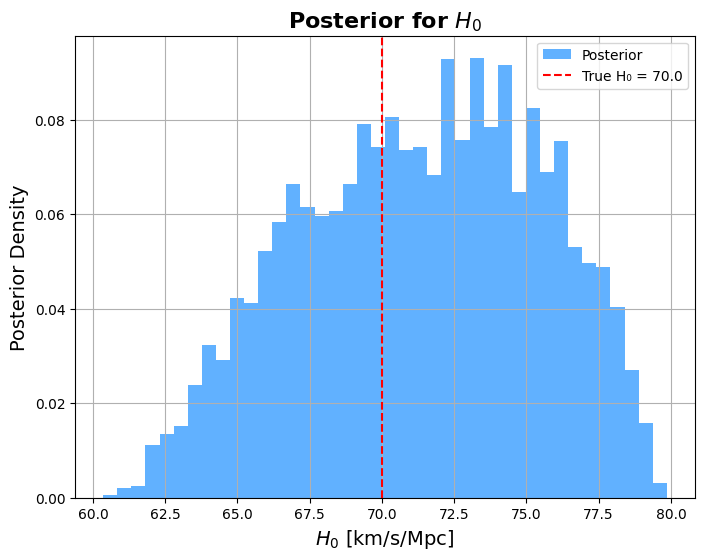

In [16]:
# --- Step 7: Create Plots ---
# Plot and save the posterior distribution of H₀

print("Creating plots...")

# Histogram of posterior samples for H₀
plt.figure(figsize=(8, 6))
plt.hist(samples[:, 0], bins=40, weights=weights, density=True,
         alpha=0.7, label='Posterior', color='dodgerblue')

# Reference line for true H₀
plt.axvline(H0_fid, color='red', linestyle='--', label=f'True H₀ = {H0_fid:.1f}')

# Axis labels and title
plt.xlabel(r'$H_0$ [km/s/Mpc]', fontsize=14)
plt.ylabel('Posterior Density', fontsize=14)
plt.title('Posterior for $H_0$', fontsize=16, fontweight='bold')

# Legend and grid
plt.legend()
plt.grid(True)

# Save plot to file
plt.savefig('plots/posterior_H0.png', dpi=300, bbox_inches='tight')
plt.show()

- **Trace Plot Generation**


Creating additional analysis plots...


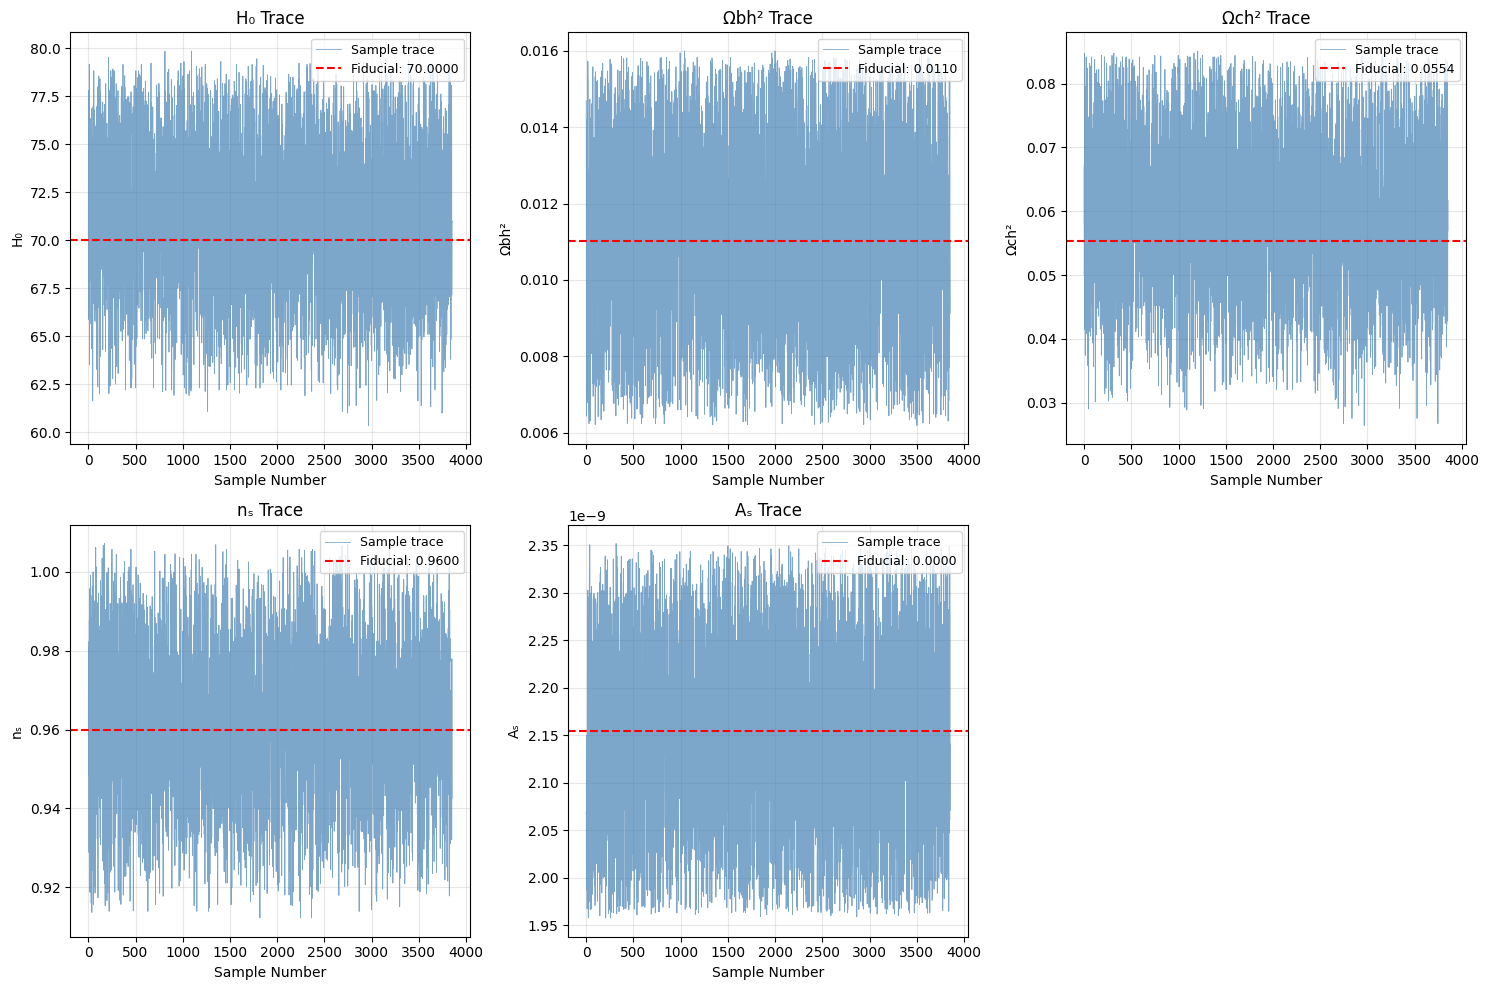

In [17]:
# --- Step 8: Additional Analysis Plots ---
# Generate trace plots to assess MCMC convergence across parameters.

print("\nCreating additional analysis plots...")

# Initialize subplots for parameter traces
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

# Iterate over parameters and plot sample evolution
for i, name in enumerate(params_names):
    if i < len(axes):
        axes[i].plot(samples[:, i], alpha=0.7, linewidth=0.6, color='steelblue', label='Sample trace')
        axes[i].axhline(y=fiducial_values[i], color='red', linestyle='--', label=f'Fiducial: {fiducial_values[i]:.4f}')
        axes[i].set_title(f'{name} Trace', fontsize=12)
        axes[i].set_xlabel('Sample Number', fontsize=10)
        axes[i].set_ylabel(name, fontsize=10)
        axes[i].legend(loc='upper right', fontsize=9)
        axes[i].grid(True, alpha=0.3)

# Remove unused subplot if necessary
if len(params_names) < len(axes):
    fig.delaxes(axes[-1])

# Optimize layout and save figure
plt.tight_layout()
plt.savefig('plots/trace_plots.png', dpi=300, bbox_inches='tight')
plt.show()

- **Corner & Triangle Plot Visualization**


Creating corner plots...


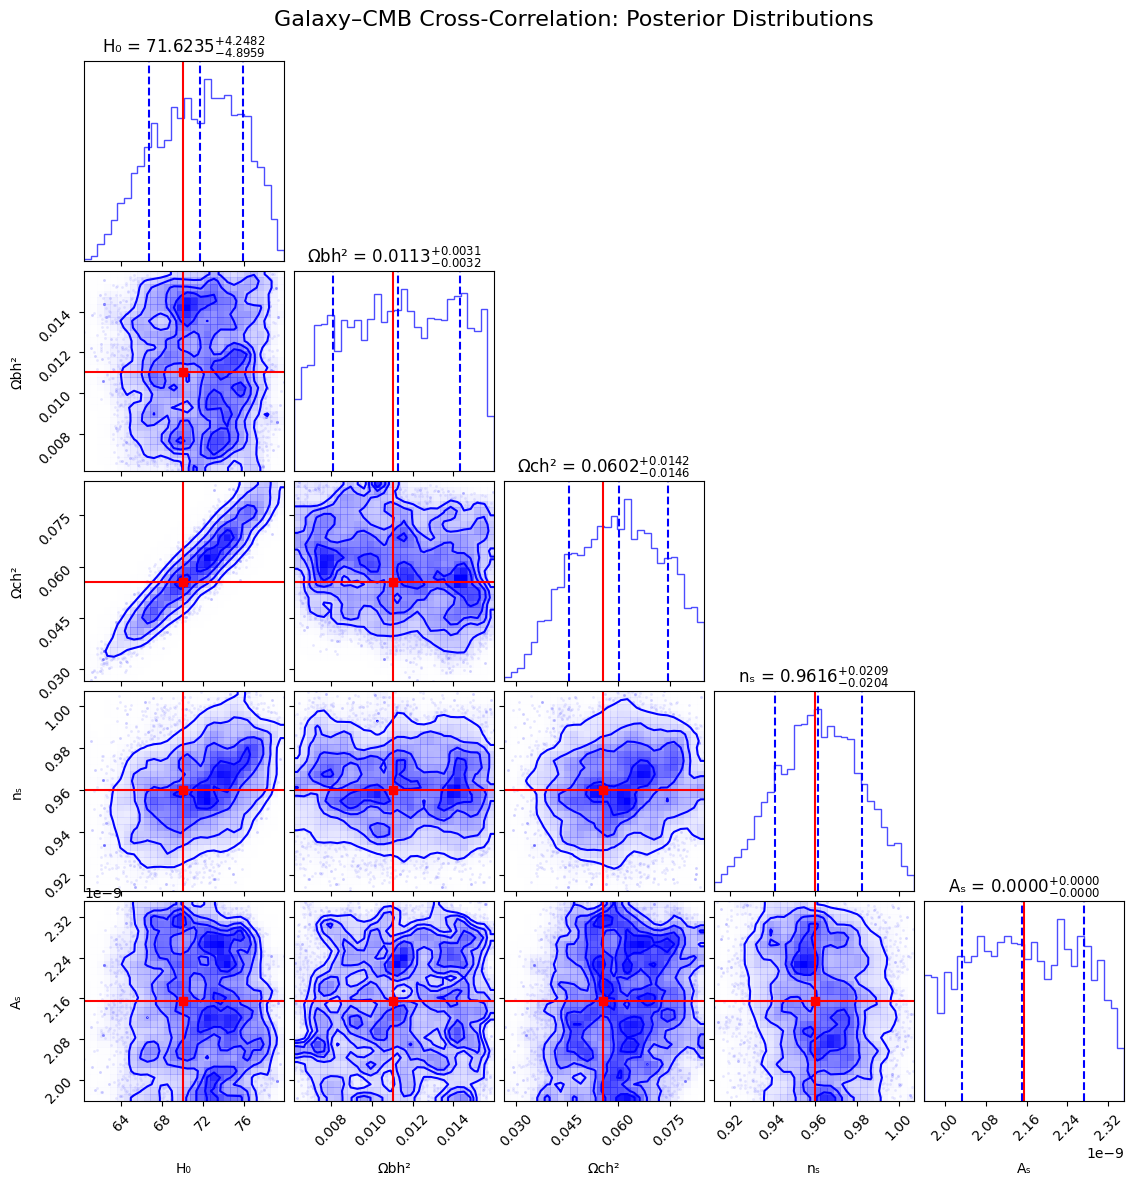

Creating GetDist triangle plot...
Removed no burn in


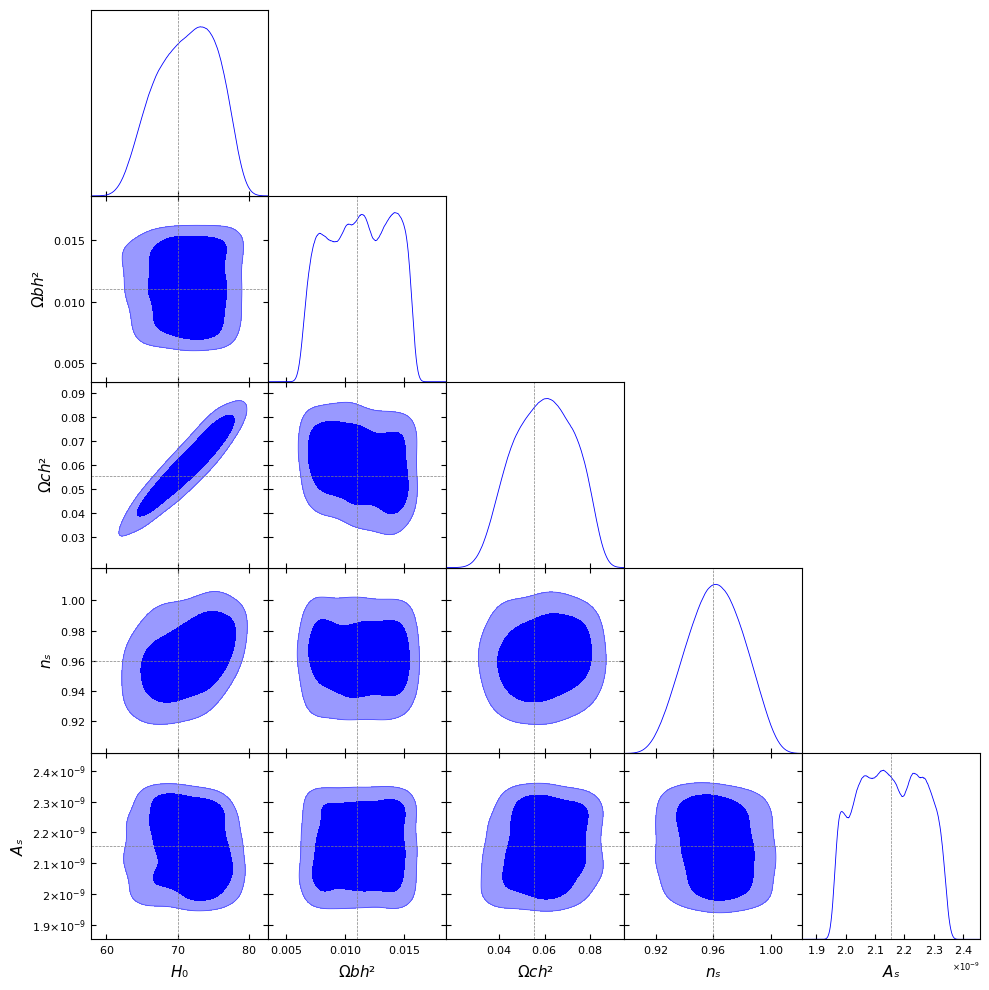

In [18]:
# --- Step 9: Generate Posterior Corner Plots ---
# Visualizes marginalized parameter distributions and correlations using two methods.

print("\nCreating corner plots...")

# 9A. Generate corner plot using corner.py
try:
    fig = corner.corner(
        samples,
        labels=params_names,
        truths=fiducial_values,
        weights=weights,
        show_titles=True,
        title_kwargs={"fontsize": 12},
        quantiles=[0.16, 0.5, 0.84],
        title_fmt='.4f',
        smooth=1.0,
        bins=30,
        color='blue',
        truth_color='red',
        hist_kwargs={'density': True, 'alpha': 0.7},
        scatter_kwargs={'alpha': 0.3, 's': 10}
    )

    fig.suptitle('Galaxy–CMB Cross-Correlation: Posterior Distributions', 
                 fontsize=16, y=1.01)

    plt.savefig('plots/corner_plot_corner.png', dpi=300, bbox_inches='tight')
    plt.show()

except Exception as e:
    print(f"corner.py plot failed: {e}")

# 9B. Generate triangle plot using GetDist
try:
    from getdist import MCSamples, plots as gd_plots

    print("Creating GetDist triangle plot...")

    samples_gd = MCSamples(samples=samples, weights=weights, names=params_names, labels=params_names)

    g = gd_plots.get_subplot_plotter()
    g.triangle_plot([samples_gd], filled=True, contour_colors=['blue'],
                    markers=dict(zip(params_names, fiducial_values)))
    
    plt.savefig('plots/corner_plot_getdist.png', dpi=300, bbox_inches='tight')
    plt.show()

except Exception as e:
    print(f"GetDist plot failed: {e}")